In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('fuel.csv')
df.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


In [4]:
df.isnull().sum()

YEAR                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
HWY (L/100 km)      0
COMB (L/100 km)     0
COMB (mpg)          0
EMISSIONS           0
dtype: int64

In [5]:
numerical_cols = ['ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION', 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'EMISSIONS']
data = df[numerical_cols].copy()
data.head()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,1.6,4,9.2,6.7,8.1,35,186
1,1.6,4,8.5,6.5,7.6,37,175
2,3.2,6,12.2,7.4,10.0,28,230
3,3.5,6,13.4,9.2,11.5,25,264
4,1.8,4,10.0,7.0,8.6,33,198


In [6]:
data_before = data.copy()
data = data.dropna()
data.shape

(22556, 7)

In [7]:
data_before.describe()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
count,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000
mean,3.356646,5.854141,12.763513,8.919126,11.034341,27.374534,250.068452
std,1.335425,1.819597,3.500999,2.274764,2.910920,7.376982,59.355276
min,0.800000,2.000000,3.500000,3.200000,3.600000,11.000000,83.000000
25%,2.300000,4.000000,10.400000,7.300000,9.100000,22.000000,209.000000
50%,3.000000,6.000000,12.300000,8.400000,10.600000,27.000000,243.000000
75%,4.200000,8.000000,14.725000,10.200000,12.700000,31.000000,288.000000
max,8.400000,16.000000,30.600000,20.900000,26.100000,78.000000,608.000000


In [8]:
mean = data.mean()
std = data.std()
standardized_data = (data - mean) / std
standardized_data.head()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,-1.315421,-1.018984,-1.017856,-0.975541,-1.008046,1.033684,-1.079406
1,-1.315421,-1.018984,-1.217799,-1.063462,-1.179813,1.304797,-1.264731
2,-0.117300,0.080160,-0.160958,-0.667817,-0.355331,0.084786,-0.338107
3,0.107347,0.080160,0.181802,0.123474,0.159970,-0.321884,0.234715
4,-1.165655,-1.018984,-0.789350,-0.843659,-0.836279,0.762570,-0.877234


In [9]:
X = standardized_data.values
n = X.shape[0]
covariance_matrix = np.dot(X.T, X) / (n - 1)
covariance_matrix

array([[ 1.        ,  0.9133774 ,  0.82160502,  0.7493943 ,  0.80731635,
        -0.75500173,  0.82128488],
       [ 0.9133774 ,  1.        ,  0.79494251,  0.69834389,  0.77158708,
        -0.71421461,  0.80217631],
       [ 0.82160502,  0.79494251,  1.        ,  0.94235124,  0.99295989,
        -0.92136058,  0.91910056],
       [ 0.7493943 ,  0.69834389,  0.94235124,  1.        ,  0.97501426,
        -0.88474415,  0.89478067],
       [ 0.80731635,  0.77158708,  0.99295989,  0.97501426,  1.        ,
        -0.92091487,  0.92298258],
       [-0.75500173, -0.71421461, -0.92136058, -0.88474415, -0.92091487,
         1.        , -0.90184372],
       [ 0.82128488,  0.80217631,  0.91910056,  0.89478067,  0.92298258,
        -0.90184372,  1.        ]])

In [10]:
cov_df = pd.DataFrame(covariance_matrix, columns=data.columns, index=data.columns)
cov_df

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
ENGINE SIZE,1.000000,0.913377,0.821605,0.749394,0.807316,-0.755002,0.821285
CYLINDERS,0.913377,1.000000,0.794943,0.698344,0.771587,-0.714215,0.802176
FUEL CONSUMPTION,0.821605,0.794943,1.000000,0.942351,0.992960,-0.921361,0.919101
HWY (L/100 km),0.749394,0.698344,0.942351,1.000000,0.975014,-0.884744,0.894781
COMB (L/100 km),0.807316,0.771587,0.992960,0.975014,1.000000,-0.920915,0.922983
COMB (mpg),-0.755002,-0.714215,-0.921361,-0.884744,-0.920915,1.000000,-0.901844
EMISSIONS,0.821285,0.802176,0.919101,0.894781,0.922983,-0.901844,1.000000


In [11]:
def power_iteration(A, num_iterations=1000):
    n = A.shape[0]
    eigenvalues = []
    eigenvectors = []
    A_copy = A.copy()
    
    for i in range(n):
        b_k = np.random.rand(n)
        for _ in range(num_iterations):
            b_k1 = np.dot(A_copy, b_k)
            b_k1_norm = np.linalg.norm(b_k1)
            b_k = b_k1 / b_k1_norm
        
        eigenvalue = np.dot(b_k.T, np.dot(A_copy, b_k))
        eigenvalues.append(eigenvalue)
        eigenvectors.append(b_k)
        
        A_copy = A_copy - eigenvalue * np.outer(b_k, b_k)
    
    return np.array(eigenvalues), np.array(eigenvectors).T

eigenvalues, eigenvectors = power_iteration(covariance_matrix)
eigenvalues

array([6.13178940e+00, 5.17162299e-01, 1.33929185e-01, 9.32127022e-02,
       8.31172662e-02, 4.06362951e-02, 1.52853724e-04])

In [12]:
eigenvectors

array([[ 3.60391953e-01,  5.44556727e-01,  9.71413051e-02,
        -4.74007627e-01,  5.78708224e-01,  6.74698309e-02,
        -7.49313869e-04],
       [ 3.49339803e-01,  6.45154999e-01, -3.15601907e-03,
         2.82115783e-01, -5.63358593e-01, -2.54487202e-01,
         9.01975757e-04],
       [ 3.94965702e-01, -1.64973781e-01,  1.88705619e-01,
        -1.12651278e-01, -2.89467832e-01,  6.35645624e-01,
        -5.29762815e-01],
       [ 3.80138515e-01, -3.51298362e-01,  4.87419920e-01,
         8.39439848e-02,  1.52814610e-01, -6.21024543e-01,
        -2.80063583e-01],
       [ 3.95037660e-01, -2.32520717e-01,  2.94573027e-01,
        -4.51763608e-02, -1.36389785e-01,  2.03838483e-01,
         8.00570353e-01],
       [-3.76919681e-01,  2.79479198e-01,  6.96148165e-01,
         4.39015394e-01,  1.83931737e-01,  2.61982998e-01,
         4.15967142e-04],
       [ 3.86591448e-01, -6.65703007e-02, -3.82060311e-01,
         6.93696714e-01,  4.33759033e-01,  1.75448069e-01,
        -1.1448922

In [13]:
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

sorted_eigenvalues

array([6.13178940e+00, 5.17162299e-01, 1.33929185e-01, 9.32127022e-02,
       8.31172662e-02, 4.06362951e-02, 1.52853724e-04])

In [14]:
sorted_eigenvectors

array([[ 3.60391953e-01,  5.44556727e-01,  9.71413051e-02,
        -4.74007627e-01,  5.78708224e-01,  6.74698309e-02,
        -7.49313869e-04],
       [ 3.49339803e-01,  6.45154999e-01, -3.15601907e-03,
         2.82115783e-01, -5.63358593e-01, -2.54487202e-01,
         9.01975757e-04],
       [ 3.94965702e-01, -1.64973781e-01,  1.88705619e-01,
        -1.12651278e-01, -2.89467832e-01,  6.35645624e-01,
        -5.29762815e-01],
       [ 3.80138515e-01, -3.51298362e-01,  4.87419920e-01,
         8.39439848e-02,  1.52814610e-01, -6.21024543e-01,
        -2.80063583e-01],
       [ 3.95037660e-01, -2.32520717e-01,  2.94573027e-01,
        -4.51763608e-02, -1.36389785e-01,  2.03838483e-01,
         8.00570353e-01],
       [-3.76919681e-01,  2.79479198e-01,  6.96148165e-01,
         4.39015394e-01,  1.83931737e-01,  2.61982998e-01,
         4.15967142e-04],
       [ 3.86591448e-01, -6.65703007e-02, -3.82060311e-01,
         6.93696714e-01,  4.33759033e-01,  1.75448069e-01,
        -1.1448922

In [15]:
k = 2
top_k_eigenvectors = sorted_eigenvectors[:, :k]
top_k_eigenvectors

array([[ 0.36039195,  0.54455673],
       [ 0.3493398 ,  0.645155  ],
       [ 0.3949657 , -0.16497378],
       [ 0.38013852, -0.35129836],
       [ 0.39503766, -0.23252072],
       [-0.37691968,  0.2794792 ],
       [ 0.38659145, -0.0665703 ]])

In [16]:
transformed_data = np.dot(X, top_k_eigenvectors)
transformed_data.shape

(22556, 2)

In [17]:
transformed_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])
transformed_df.head()

,PC1,PC2
0,-2.808019,-0.267957
1,-3.162099,-0.076038
2,-0.634743,0.377822
3,0.460690,-0.105978
4,-2.365459,-0.399598


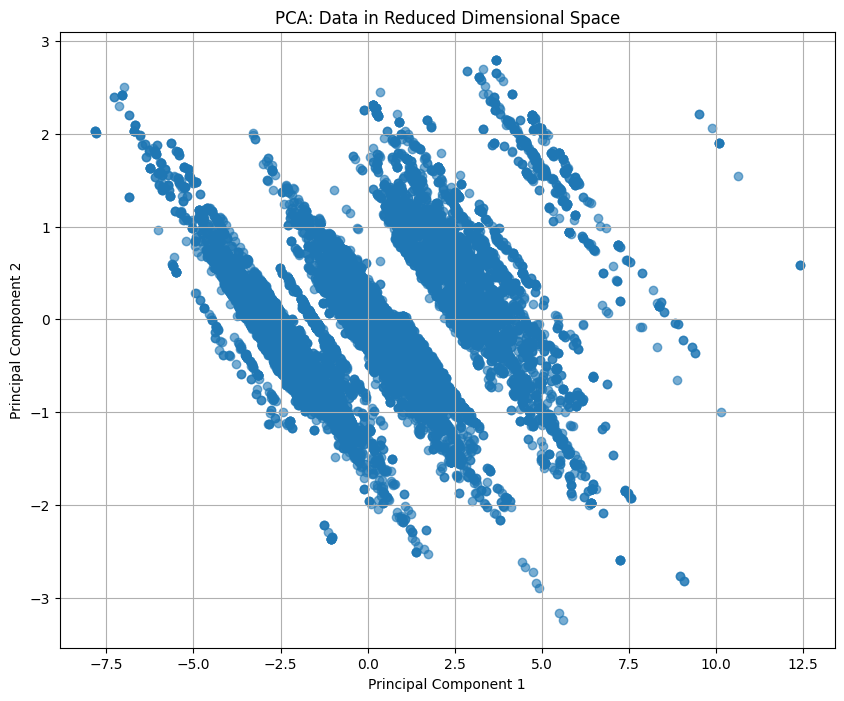

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Data in Reduced Dimensional Space')
plt.grid(True)
plt.show()